LSTM + Attention Mechanism for clustering latent dim

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import os

In [66]:
import tensorflow as tf
from tensorflow.keras import Model, Input, regularizers
from tensorflow.keras.layers import (
    LSTM, Dense, Flatten, Activation, RepeatVector, Permute, Multiply, 
    Lambda, Dropout, BatchNormalization, TimeDistributed
)
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.layers import Layer

class ReduceSumLayer(Layer):
    def call(self, inputs):
        return tf.reduce_sum(inputs, axis=1)

class LSTMAttentionAutoencoder:
    def __init__(self, 
                 input_shape=(51, 2),
                 latent_dim=16, 
                 lstm_units=[64, 32],
                 dropout_rate=0.3, 
                 l2_reg=1e-4):
        
        self.input_shape = input_shape
        self.latent_dim = latent_dim
        self.lstm_units = lstm_units
        self.dropout_rate = dropout_rate
        self.l2_reg = l2_reg
        self.model, self.encoder = self._build_model()
    
    def _attention_block(self, lstm_out):
        attention = Dense(1, activation='tanh')(lstm_out)
        attention = Flatten()(attention)
        attention = Activation('softmax')(attention)
        attention = RepeatVector(self.lstm_units[-1])(attention)
        attention = Permute([2, 1])(attention)
        weighted = Multiply()([lstm_out, attention])
        context_vector = ReduceSumLayer()(weighted)
        return context_vector

    def _build_model(self):
        # Encoder
        inputs = Input(shape=self.input_shape)
        x = inputs
        for i, units in enumerate(self.lstm_units):
            x = LSTM(units, return_sequences=True,
                     kernel_regularizer=regularizers.l2(self.l2_reg))(x)
            x = BatchNormalization()(x)
            x = Dropout(self.dropout_rate)(x)
        context_vector = self._attention_block(x)
        x = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(self.l2_reg))(context_vector)
        x = BatchNormalization()(x)
        x = Dropout(self.dropout_rate)(x)
        latent = Dense(self.latent_dim, name='latent_vector')(x)

        # Decoder
        x = Dense(64, activation='relu')(latent)
        x = RepeatVector(self.input_shape[0])(x)  # Repeat for time steps
        for units in reversed(self.lstm_units):
            x = LSTM(units, return_sequences=True)(x)
            x = BatchNormalization()(x)
            x = Dropout(self.dropout_rate)(x)
        outputs = TimeDistributed(Dense(self.input_shape[1]))(x)  # Output shape: (batch, 51, 2)

        # Models
        autoencoder = Model(inputs, outputs, name="LSTM_Attention_Autoencoder")
        encoder = Model(inputs, latent, name="Encoder")
        return autoencoder, encoder

    def compile(self, learning_rate=1e-3):
        self.model.compile(optimizer=Adam(learning_rate), loss='mse')

    def train(self, X_train, epochs=50, batch_size=16, verbose=1):
        self.model.fit(X_train, X_train, epochs=epochs, batch_size=batch_size, verbose=verbose)

    def get_latent_vectors(self, X):
        return self.encoder.predict(X)

    def summary(self):
        self.model.summary()

In [67]:
#loading data 
data = pd.read_csv(r"C:\Users\Admin\Desktop\CP\Data\processed\final_processed\GAIT_analysis_dataset.csv")

In [68]:
data

,Patient ID,aSagH_0,aSagH_2,aSagH_4,aSagH_6,aSagH_8,aSagH_10,aSagH_12,aSagH_14,aSagH_16,...,aSagK_82,aSagK_84,aSagK_86,aSagK_88,aSagK_90,aSagK_92,aSagK_94,aSagK_96,aSagK_98,aSagK_100
0,1,34.489231,33.190099,31.611866,29.735892,27.653619,25.561388,23.659099,22.070589,20.809243,...,50.180644,48.361048,45.747773,42.545444,39.002017,35.373413,31.893023,28.766132,26.183560,24.284412
1,2,34.115943,33.845007,33.142873,32.425595,31.833842,31.200395,30.316142,29.124648,27.683478,...,36.856681,41.823153,45.755571,47.958314,48.090432,46.405582,43.682483,40.756274,38.099251,35.805094
2,3,46.266824,43.885923,41.490654,39.073092,36.650765,34.278363,32.022496,29.928085,27.998026,...,56.275353,53.910564,50.906875,47.310920,43.265528,39.025186,34.929357,31.336358,28.524134,26.583531
3,4,31.919585,29.332622,26.944135,24.833541,23.089692,21.746950,20.720097,19.807280,18.798043,...,56.399781,54.999984,52.696951,49.514561,45.606221,41.252328,36.805056,32.613890,28.952887,25.959657
4,5,34.398839,32.395244,30.418174,28.569600,26.850805,25.226143,23.697601,22.251928,20.845959,...,46.017507,42.047962,37.776869,33.473623,29.385098,25.673032,22.376516,19.419898,16.719602,14.333492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,CP152,42.429747,40.102682,36.755350,33.408856,30.922122,27.753506,24.640012,21.544426,18.561348,...,55.231592,53.383502,50.746365,47.185969,42.841141,37.997811,33.205888,28.943379,25.484040,22.766658
547,CP170,27.045223,26.060930,25.342578,24.680958,23.506208,21.747387,20.011563,18.636352,17.367513,...,55.361977,51.864558,47.604370,42.820967,37.690930,32.667078,28.316491,25.181901,23.573280,23.235346
548,CP195,43.094113,41.603654,40.014215,38.368341,36.680087,34.948594,33.165763,31.316489,29.379185,...,45.633593,41.745998,36.806451,31.039062,24.971145,19.298280,14.674303,11.439663,9.590914,9.137108
549,CP83,29.389849,28.819173,28.800633,28.806647,28.425304,27.505517,26.088310,24.249631,22.013928,...,42.732546,37.010111,31.439729,26.273291,21.687163,17.841182,14.871403,12.842567,11.731675,11.424054


In [69]:
#split into train and test data
# Get unique patient IDs
unique_patients = data['Patient ID'].unique()

# Split patient IDs into train and test sets (e.g., 80% train, 20% test)
train_patients, test_patients = train_test_split(unique_patients, test_size=0.25, random_state=7)

# Create train and test DataFrames
train_df = data[data['Patient ID'].isin(train_patients)].reset_index(drop=True)
test_df = data[data['Patient ID'].isin(test_patients)].reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train patients:", train_df['Patient ID'].nunique())
print("Test patients:", test_df['Patient ID'].nunique())


Train shape: (413, 103)
Test shape: (138, 103)
Train patients: 413
Test patients: 138


In [70]:
# Before extracting patient_sequences, fill NaNs in train_df and test_df
train_df = train_df.interpolate(axis=0).fillna(method='bfill').fillna(method='ffill')
test_df = test_df.interpolate(axis=0).fillna(method='bfill').fillna(method='ffill')

C:\Users\Admin\AppData\Local\Temp\ipykernel_25512\4135663483.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  train_df = train_df.interpolate(axis=0).fillna(method='bfill').fillna(method='ffill')
C:\Users\Admin\AppData\Local\Temp\ipykernel_25512\4135663483.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df = train_df.interpolate(axis=0).fillna(method='bfill').fillna(method='ffill')
C:\Users\Admin\AppData\Local\Temp\ipykernel_25512\4135663483.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  test_df = test_df.interpolate(axis=0).fillna(method='bfill').fillna(method='ffill')
C:\Users\Admin\AppData\Local\Temp\ipykernel_25512\4135663483.

In [71]:
hip_cols = [col for col in train_df.columns if col.startswith('aSagH_')]
knee_cols = [col for col in train_df.columns if col.startswith('aSagK_')]

patient_sequences = []
patient_ids = []

for pid in train_df['Patient ID'].unique():
    hip_data = train_df[train_df['Patient ID'] == pid][hip_cols].values.flatten()
    knee_data = train_df[train_df['Patient ID'] == pid][knee_cols].values.flatten()
    # Stack as (51, 2): columns are [knee, hip]
    if len(hip_data) == 51 and len(knee_data) == 51:
        patient_sequence = np.stack([knee_data, hip_data], axis=1)  # shape (51, 2)
        patient_sequences.append(patient_sequence)
        patient_ids.append(pid)

# Convert to numpy array
X_train = np.array(patient_sequences)
X_train_patient_ids = np.array(patient_ids)
print("Patient sequences shape:", X_train.shape)
print("Patient IDs shape:", X_train_patient_ids.shape)

Patient sequences shape: (413, 51, 2)
Patient IDs shape: (413,)


In [72]:
hip_cols = [col for col in test_df.columns if col.startswith('aSagH_')]
knee_cols = [col for col in test_df.columns if col.startswith('aSagK_')]

patient_sequences = []
patient_ids = []

for pid in test_df['Patient ID'].unique():
    hip_data = test_df[test_df['Patient ID'] == pid][hip_cols].values.flatten()
    knee_data = test_df[test_df['Patient ID'] == pid][knee_cols].values.flatten()
    # Stack as (51, 2): columns are [knee, hip]
    if len(hip_data) == 51 and len(knee_data) == 51:
        patient_sequence = np.stack([knee_data, hip_data], axis=1)  # shape (51, 2)
        patient_sequences.append(patient_sequence)
        patient_ids.append(pid)

# Convert to numpy array
X_test = np.array(patient_sequences)
X_test_patient_ids = np.array(patient_ids)
print("Patient sequences shape:", X_test.shape)
print("Patient IDs shape:", X_test_patient_ids.shape)

Patient sequences shape: (138, 51, 2)
Patient IDs shape: (138,)


In [73]:
#scaling the data

# Reshape to 2D for scaling: (num_patients * 51, 2)
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)

# Reshape back to original shape
X_train = X_train_scaled.reshape(X_train.shape)
X_test = X_test_scaled.reshape(X_test.shape)

In [52]:
import keras_tuner as kt

def build_model(hp):
    latent_dim = hp.Int('latent_dim', min_value=8, max_value=64, step=8)
    lstm_units_1 = hp.Int('lstm_units_1', min_value=16, max_value=128, step=16)
    lstm_units_2 = hp.Int('lstm_units_2', min_value=8, max_value=64, step=8)
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
    l2_reg = hp.Float('l2_reg', min_value=1e-5, max_value=1e-3, sampling='log')
    
    model = LSTMAttentionAutoencoder(
        input_shape=(51, 2),
        latent_dim=latent_dim,
        lstm_units=[lstm_units_1, lstm_units_2],
        dropout_rate=dropout_rate,
        l2_reg=l2_reg
    )
    model.compile()
    return model.model  # Return the autoencoder (not just encoder)

In [53]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory=r'C:\Users\Admin\Desktop\CP\Outputs\HP Tuning\tuner_results',
    project_name='lstm_attention_autoencoder'
)

In [54]:
tuner.search(X_train, X_train, epochs=30, batch_size=16, validation_split=0.2)

Trial 10 Complete [00h 02m 16s]
val_loss: 0.01859300024807453

Best val_loss So Far: 0.01859300024807453
Total elapsed time: 00h 19m 29s


In [55]:
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:", best_hp.values)

best_model = tuner.get_best_models(1)[0]

Best hyperparameters: {'latent_dim': 24, 'lstm_units_1': 96, 'lstm_units_2': 8, 'dropout_rate': 0.1, 'l2_reg': 2.3761964881131694e-05}


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 66 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [56]:
best_model.save(r'C:\Users\Admin\Desktop\CP\Outputs\HP Tuning\model\best_lstm_attention_autoencoder.h5')
best_model.save(r'C:\Users\Admin\Desktop\CP\Outputs\HP Tuning\model\best_lstm_attention_autoencoder.keras')

In [38]:
import json

history = best_model.history.history if hasattr(best_model, 'history') else None
if history:
    with open(r'C:\Users\Admin\Desktop\CP\Outputs\HP Tuning\json\best_model_history.json', 'w') as f:
        json.dump(history, f)

In [39]:
history = best_model.fit(X_train, X_train, epochs=30, batch_size=16, validation_split=0.2)
with open(r'C:\Users\Admin\Desktop\CP\Outputs\HP Tuning\json\best_model_history.json', 'w') as f:
    json.dump(history.history, f)

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step - loss: 0.0641 - val_loss: 0.0395
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0557 - val_loss: 0.0281
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0499 - val_loss: 0.0409
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0439 - val_loss: 0.0282
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0380 - val_loss: 0.0234
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0323 - val_loss: 0.0259
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0278 - val_loss: 0.0203
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0256 - val_loss: 0.0178
Epoch 9/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0231 - val_loss: 0.0149
Epoch 10/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0215 - val_loss: 0.0159
Epoch 11/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0201 - val_loss: 0.0192
Epoch 12/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 22s 220ms/step - loss: 1.1003 - mae: 0.7911 - val_loss: 0.1416 - val_mae: 0.3334
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.4132 - mae: 0.5001 - val_loss: 0.0670 - val_mae: 0.2102
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.2712 - mae: 0.3988 - val_loss: 0.0436 - val_mae: 0.1643
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.2442 - mae: 0.3774 - val_loss: 0.0351 - val_mae: 0.1486
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.2239 - mae: 0.3591 - val_loss: 0.0331 - val_mae: 0.1448
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.2092 - mae: 0.3494 - val_loss: 0.0338 - val_mae: 0.1458
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.2013 - mae: 0.3442 - val_loss: 0.0345 - val_mae: 0.1462
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.1970 - mae: 0.3389 - val_loss: 0.0322 - val_mae: 0.1418
Epoch 9/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Admin\\Desktop\\CP\\Outputs\\HP Tuning\\plots\\loss_mae_curve.png'

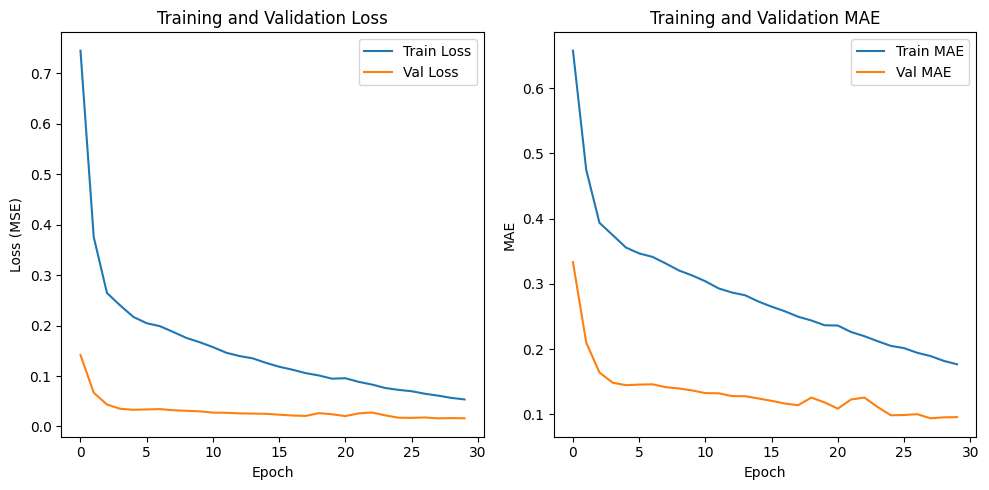

In [ ]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import json
import numpy as np
import keras

#Best hyperparameters: {'latent_dim': 24, 'lstm_units_1': 96, 'lstm_units_2': 8, 'dropout_rate': 0.1, 'l2_reg': 2.3761964881131694e-05}

best_model = LSTMAttentionAutoencoder(
    X_train.shape[1:], 
    latent_dim=24, 
    lstm_units=[96, 8], 
    dropout_rate=0.1, 
    l2_reg=2.3761964881131694e-05
)

# Compile with loss and metrics
best_model.model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']  # You can add more metrics if needed
)

# Fine-tune the model
history = best_model.model.fit(
    X_train, X_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    shuffle=True
)

# Evaluate on test data
test_loss, test_mae = best_model.model.evaluate(X_test, X_test)
print("Test loss (MSE):", test_loss)
print("Test MAE:", test_mae)

# Plot and save the loss and MAE curves
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training and Validation MAE')
plt.legend()

plt.tight_layout()
plt.savefig(r'C:\Users\Admin\Desktop\CP\Outputs\HP Tuning\loss_mae_curve.png')
plt.show()

# Save the training history as JSON
with open(r'C:\Users\Admin\Desktop\CP\Outputs\HP Tuning\json\best_model_history.json', 'w') as f:
    json.dump(history.history, f)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


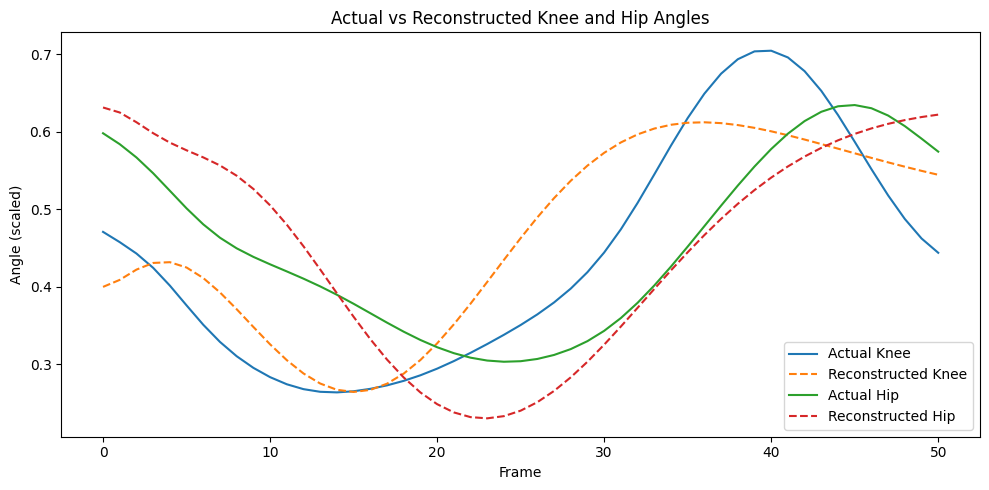

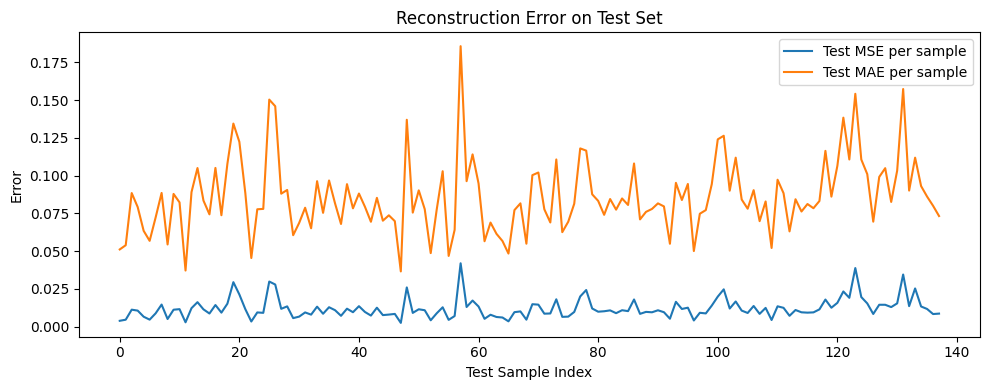

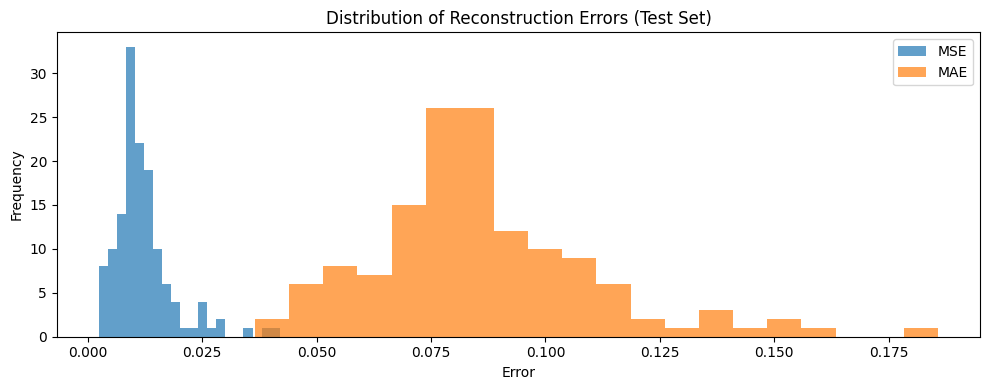

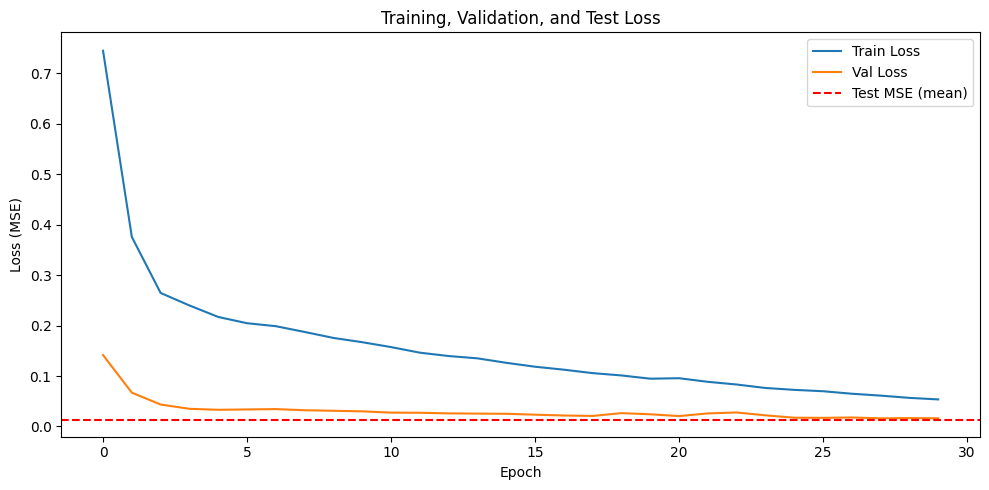

In [77]:
import matplotlib.pyplot as plt
import numpy as np

X_test_pred = best_model.model.predict(X_test)
idx = 0  # test patient index

actual = X_test[idx]
reconstructed = X_test_pred[idx]

plt.figure(figsize=(10, 5))
plt.plot(actual[:, 0], label='Actual Knee')
plt.plot(reconstructed[:, 0], label='Reconstructed Knee', linestyle='--')
plt.plot(actual[:, 1], label='Actual Hip')
plt.plot(reconstructed[:, 1], label='Reconstructed Hip', linestyle='--')
plt.title('Actual vs Reconstructed Knee and Hip Angles')
plt.xlabel('Frame')
plt.ylabel('Angle (scaled)')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\Admin\Desktop\CP\Outputs\results\plots\actual_vs_reconstructed_single.png')
plt.show()

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Compute MSE and MAE for each test sample
mse_list = [mean_squared_error(X_test[i], X_test_pred[i]) for i in range(len(X_test))]
mae_list = [mean_absolute_error(X_test[i], X_test_pred[i]) for i in range(len(X_test))]

plt.figure(figsize=(10, 4))
plt.plot(mse_list, label='Test MSE per sample')
plt.plot(mae_list, label='Test MAE per sample')
plt.xlabel('Test Sample Index')
plt.ylabel('Error')
plt.title('Reconstruction Error on Test Set')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\Admin\Desktop\CP\Outputs\results\plots\test_reconstruction_error.png')
plt.show()


plt.figure(figsize=(10, 4))
plt.hist(mse_list, bins=20, alpha=0.7, label='MSE')
plt.hist(mae_list, bins=20, alpha=0.7, label='MAE')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Distribution of Reconstruction Errors (Test Set)')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\Admin\Desktop\CP\Outputs\results\plots\test_error_histogram.png')
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.axhline(np.mean(mse_list), color='red', linestyle='--', label='Test MSE (mean)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training, Validation, and Test Loss')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\Admin\Desktop\CP\Outputs\results\plots\loss_curve_with_test.png')
plt.show()

In [78]:
# Get latent vectors for train and test sets
X_train_latent = best_model.encoder.predict(X_train)
X_test_latent = best_model.encoder.predict(X_test)

print("Train latent shape:", X_train_latent.shape)
print("Test latent shape:", X_test_latent.shape)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Train latent shape: (413, 24)
Test latent shape: (138, 24)


In [79]:
from sklearn.cluster import KMeans

# Choose number of clusters (e.g., 2 or 3)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_train_latent)

print("Cluster assignments for train set:", clusters)

Cluster assignments for train set: [3 1 1 1 3 1 0 2 3 0 1 3 3 3 1 1 2 1 1 0 3 3 0 1 3 0 0 1 3 1 1 3 1 3 1 2 3
 0 0 1 3 3 0 1 0 2 2 3 3 3 0 1 2 1 1 2 0 2 2 0 0 0 2 1 3 2 0 2 3 3 3 0 2 0
 0 2 3 0 3 2 3 0 2 0 2 2 1 3 1 2 0 1 3 3 3 0 1 1 1 1 3 3 3 0 2 2 3 3 0 2 2
 3 0 0 1 2 1 3 2 3 1 3 3 3 0 3 0 1 3 3 1 0 1 3 3 0 3 3 3 3 1 0 2 0 0 1 3 1
 1 0 1 1 2 3 0 2 0 3 1 3 3 1 1 0 2 2 2 0 1 3 3 2 3 0 2 3 1 1 1 0 3 3 0 3 2
 3 3 0 3 0 0 0 1 0 0 0 3 2 0 0 0 0 1 3 1 3 2 3 3 1 1 0 1 1 2 0 3 1 2 0 0 1
 2 2 1 3 3 1 1 2 1 1 3 0 3 3 3 3 3 3 3 1 1 2 3 0 1 0 0 0 0 1 0 1 0 3 3 3 1
 2 3 2 0 3 3 3 2 0 3 1 3 3 1 3 1 1 0 3 1 3 1 3 3 1 1 3 3 3 3 1 3 3 1 3 3 1
 1 1 3 1 3 1 1 3 1 3 3 3 3 1 3 1 1 3 3 3 3 3 1 3 3 1 3 3 3 3 3 2 2 1 2 1 1
 1 0 1 1 1 3 0 2 1 2 0 1 2 2 0 0 2 3 2 2 2 1 2 0 1 2 2 1 2 2 0 0 0 2 2 2 2
 0 2 0 2 0 2 2 2 2 2 2 0 2 2 2 0 2 0 0 2 2 2 2 2 3 3 0 2 3 0 3 2 1 2 0 0 2
 2 0 1 3 3 1]


In [80]:
import pandas as pd

# X_train_patient_ids contains the patient IDs in the same order as X_train_latent
cluster_df = pd.DataFrame({
    'Patient ID': X_train_patient_ids,
    'Cluster': clusters
})

print(cluster_df.head())
# Optionally, save to CSV
cluster_df.to_csv(r'C:\Users\Admin\Desktop\CP\Outputs\results\train_patient_clusters.csv', index=False)

  Patient ID  Cluster
0          2        3
1          3        1
2          5        1
3          6        1
4          7        3


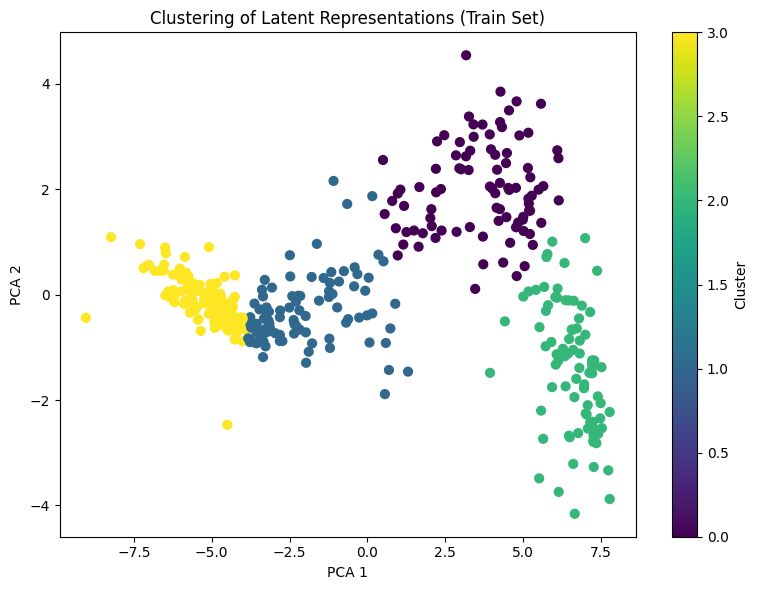

In [81]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(X_train_latent)

plt.figure(figsize=(8,6))
plt.scatter(latent_2d[:,0], latent_2d[:,1], c=clusters, cmap='viridis', s=40)
plt.title('Clustering of Latent Representations (Train Set)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.savefig(r'C:\Users\Admin\Desktop\CP\Outputs\results\plots\latent_clustering.png')
plt.show()

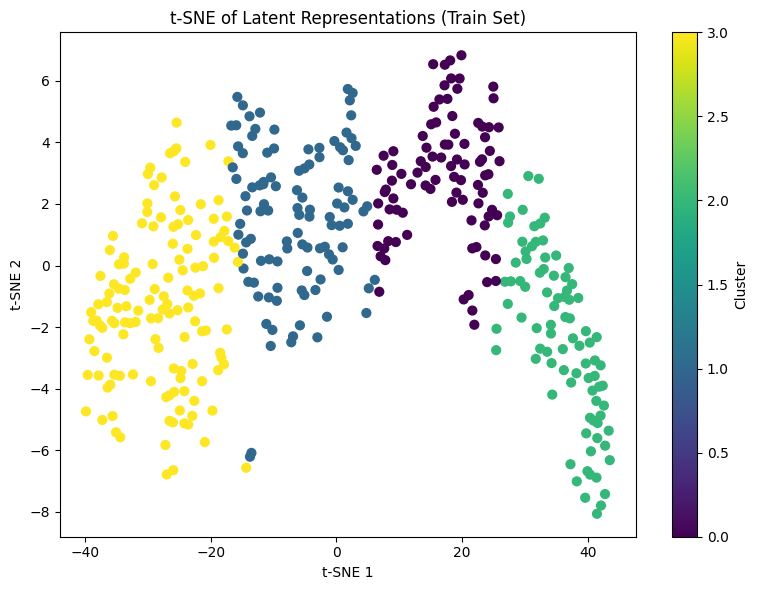

In [82]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_tsne = tsne.fit_transform(X_train_latent)

plt.figure(figsize=(8,6))
plt.scatter(latent_tsne[:,0], latent_tsne[:,1], c=clusters, cmap='viridis', s=40)
plt.title('t-SNE of Latent Representations (Train Set)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.savefig(r'C:\Users\Admin\Desktop\CP\Outputs\results\plots\latent_clustering_tsne.png')
plt.show()

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


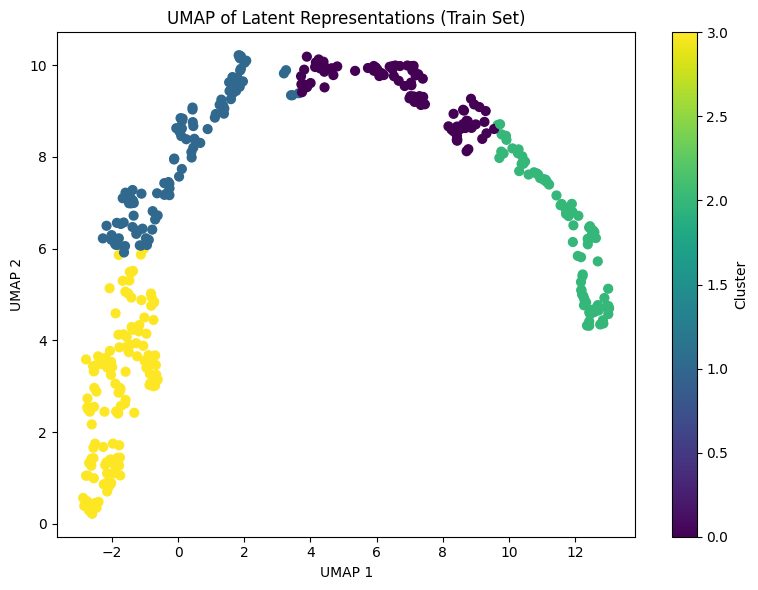

In [83]:
import umap

umap_reducer = umap.UMAP(n_components=2, random_state=42)
latent_umap = umap_reducer.fit_transform(X_train_latent)

plt.figure(figsize=(8,6))
plt.scatter(latent_umap[:,0], latent_umap[:,1], c=clusters, cmap='viridis', s=40)
plt.title('UMAP of Latent Representations (Train Set)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.savefig(r'C:\Users\Admin\Desktop\CP\Outputs\results\plots\latent_clustering_umap.png')
plt.show()

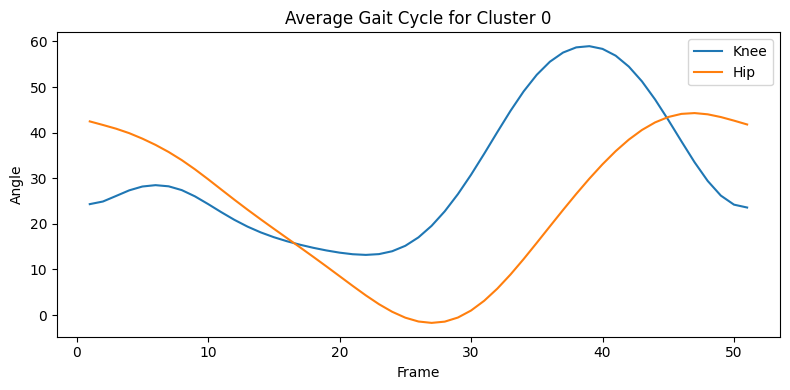

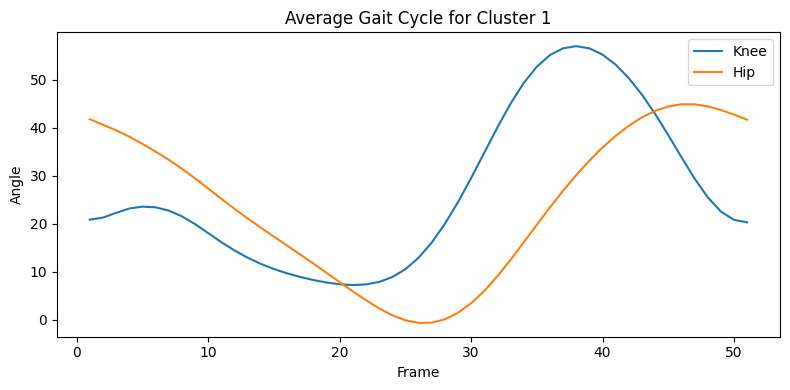

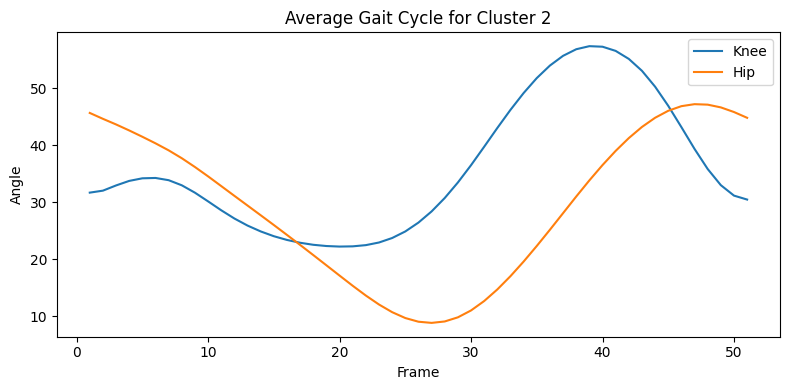

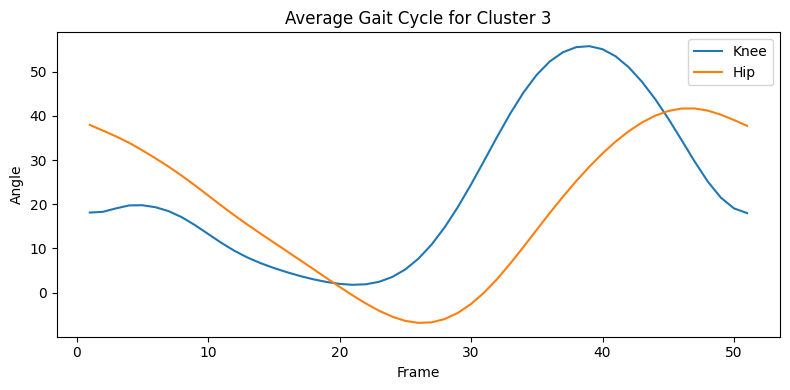

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cluster assignments
cluster_df = pd.read_csv(r'C:\Users\Admin\Desktop\CP\Outputs\results\train_patient_clusters.csv')

# Load original data
data = pd.read_csv(r"C:\Users\Admin\Desktop\CP\Data\processed\final_processed\GAIT_analysis_dataset.csv")

# Merge cluster info into original data
merged = pd.merge(data, cluster_df, on='Patient ID', how='inner')

# Get knee and hip columns
knee_cols = [col for col in merged.columns if col.startswith('aSagK_')]
hip_cols = [col for col in merged.columns if col.startswith('aSagH_')]

# Plot average gait cycle for each cluster
for cluster_id in sorted(merged['Cluster'].unique()):
    cluster_data = merged[merged['Cluster'] == cluster_id]
    # Compute mean across all patients in this cluster for each frame
    knee_mean = cluster_data[knee_cols].groupby(cluster_data['Patient ID']).mean().mean(axis=0)
    hip_mean = cluster_data[hip_cols].groupby(cluster_data['Patient ID']).mean().mean(axis=0)
    
    plt.figure(figsize=(8,4))
    plt.plot(range(1, len(knee_mean)+1), knee_mean, label='Knee')
    plt.plot(range(1, len(hip_mean)+1), hip_mean, label='Hip')
    plt.title(f'Average Gait Cycle for Cluster {cluster_id}')
    plt.xlabel('Frame')
    plt.ylabel('Angle')
    plt.legend()
    plt.tight_layout()
    plt.savefig(rf'C:\Users\Admin\Desktop\CP\Outputs\results\plots\avg_gait_cycle_cluster_{cluster_id}.png')
    plt.show()

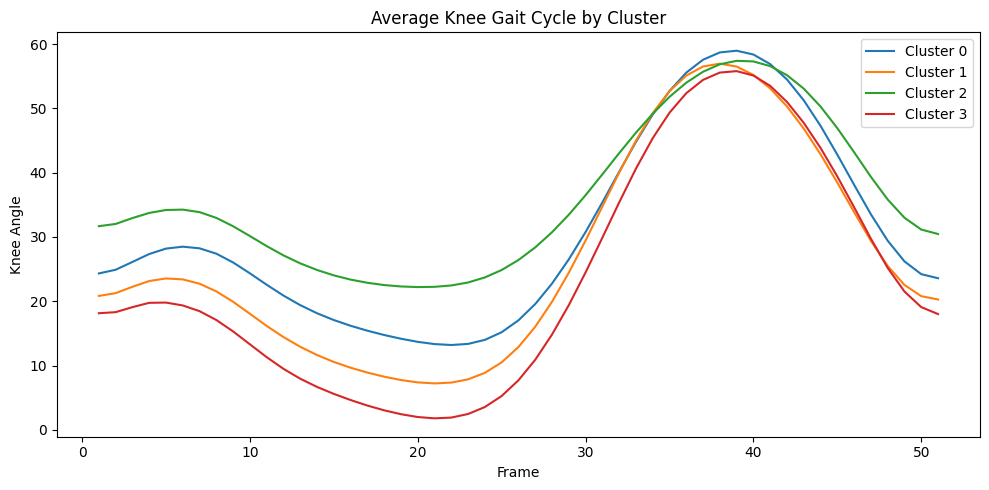

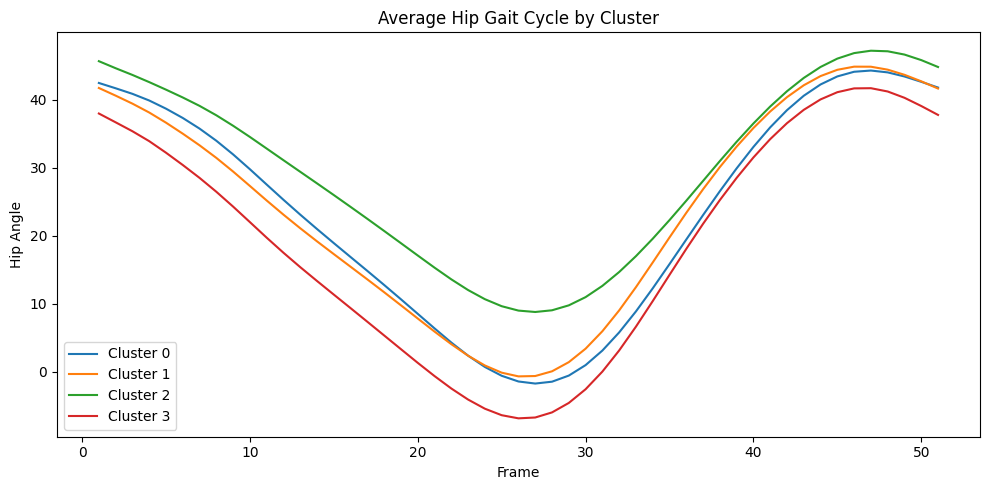

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cluster assignments
cluster_df = pd.read_csv(r'C:\Users\Admin\Desktop\CP\Outputs\results\train_patient_clusters.csv')
data = pd.read_csv(r"C:\Users\Admin\Desktop\CP\Data\processed\final_processed\GAIT_analysis_dataset.csv")
merged = pd.merge(data, cluster_df, on='Patient ID', how='inner')

knee_cols = [col for col in merged.columns if col.startswith('aSagK_')]
hip_cols = [col for col in merged.columns if col.startswith('aSagH_')]

# Prepare average cycles for each cluster
cluster_ids = sorted(merged['Cluster'].unique())
knee_means = []
hip_means = []

for cluster_id in cluster_ids:
    cluster_data = merged[merged['Cluster'] == cluster_id]
    knee_mean = cluster_data[knee_cols].groupby(cluster_data['Patient ID']).mean().mean(axis=0)
    hip_mean = cluster_data[hip_cols].groupby(cluster_data['Patient ID']).mean().mean(axis=0)
    knee_means.append(knee_mean.values)
    hip_means.append(hip_mean.values)

# Plot all clusters' average knee cycles
plt.figure(figsize=(10, 5))
for i, cluster_id in enumerate(cluster_ids):
    plt.plot(range(1, len(knee_means[i])+1), knee_means[i], label=f'Cluster {cluster_id}')
plt.title('Average Knee Gait Cycle by Cluster')
plt.xlabel('Frame')
plt.ylabel('Knee Angle')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\Admin\Desktop\CP\Outputs\results\plots\avg_gait_cycle_knee_all_clusters.png')
plt.show()

# Plot all clusters' average hip cycles
plt.figure(figsize=(10, 5))
for i, cluster_id in enumerate(cluster_ids):
    plt.plot(range(1, len(hip_means[i])+1), hip_means[i], label=f'Cluster {cluster_id}')
plt.title('Average Hip Gait Cycle by Cluster')
plt.xlabel('Frame')
plt.ylabel('Hip Angle')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\Admin\Desktop\CP\Outputs\results\plots\avg_gait_cycle_hip_all_clusters.png')
plt.show()

In [87]:
def analyze_gait_dataset(dataset_path, cluster_output_prefix):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.cluster import KMeans

    # 1. Load data
    data = pd.read_csv(dataset_path)

    # 2. Split into train/test by patient
    unique_patients = data['Patient ID'].unique()
    train_patients, test_patients = train_test_split(unique_patients, test_size=0.25, random_state=7)
    train_df = data[data['Patient ID'].isin(train_patients)].reset_index(drop=True)
    test_df = data[data['Patient ID'].isin(test_patients)].reset_index(drop=True)

    # 3. Fill NaNs
    train_df = train_df.interpolate(axis=0).fillna(method='bfill').fillna(method='ffill')
    test_df = test_df.interpolate(axis=0).fillna(method='bfill').fillna(method='ffill')

    # 4. Extract sequences
    hip_cols = [col for col in train_df.columns if col.startswith('aSagH_')]
    knee_cols = [col for col in train_df.columns if col.startswith('aSagK_')]

    def get_sequences(df):
        patient_sequences = []
        patient_ids = []
        for pid in df['Patient ID'].unique():
            hip_data = df[df['Patient ID'] == pid][hip_cols].values.flatten()
            knee_data = df[df['Patient ID'] == pid][knee_cols].values.flatten()
            if len(hip_data) == 51 and len(knee_data) == 51:
                patient_sequence = np.stack([knee_data, hip_data], axis=1)
                patient_sequences.append(patient_sequence)
                patient_ids.append(pid)
        return np.array(patient_sequences), np.array(patient_ids)

    X_train, X_train_patient_ids = get_sequences(train_df)
    X_test, X_test_patient_ids = get_sequences(test_df)

    # 5. Scale
    scaler = MinMaxScaler()
    X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
    X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])
    X_train_scaled = scaler.fit_transform(X_train_reshaped).reshape(X_train.shape)
    X_test_scaled = scaler.transform(X_test_reshaped).reshape(X_test.shape)

    # 6. Train model (reuse your LSTMAttentionAutoencoder class)
    model = LSTMAttentionAutoencoder(
        input_shape=(51, 2),
        latent_dim=24,
        lstm_units=[96, 8],
        dropout_rate=0.1,
        l2_reg=2.3761964881131694e-05
    )
    model.compile()
    model.model.fit(X_train_scaled, X_train_scaled, epochs=30, batch_size=16, validation_split=0.2, verbose=0)

    # 7. Get latent vectors and cluster
    X_train_latent = model.encoder.predict(X_train_scaled)
    n_clusters = 4
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(X_train_latent)

    # 8. Save cluster assignments
    cluster_df = pd.DataFrame({'Patient ID': X_train_patient_ids, 'Cluster': clusters})
    cluster_df.to_csv(f'{cluster_output_prefix}_clusters.csv', index=False)

    # 9. Plot average gait cycles for each cluster (knee and hip, all clusters in one plot each)
    merged = pd.merge(data, cluster_df, on='Patient ID', how='inner')
    knee_cols = [col for col in merged.columns if col.startswith('aSagK_')]
    hip_cols = [col for col in merged.columns if col.startswith('aSagH_')]
    cluster_ids = sorted(merged['Cluster'].unique())
    knee_means = []
    hip_means = []
    for cluster_id in cluster_ids:
        cluster_data = merged[merged['Cluster'] == cluster_id]
        knee_mean = cluster_data[knee_cols].groupby(cluster_data['Patient ID']).mean().mean(axis=0)
        hip_mean = cluster_data[hip_cols].groupby(cluster_data['Patient ID']).mean().mean(axis=0)
        knee_means.append(knee_mean.values)
        hip_means.append(hip_mean.values)

    plt.figure(figsize=(10, 5))
    for i, cluster_id in enumerate(cluster_ids):
        plt.plot(range(1, len(knee_means[i])+1), knee_means[i], label=f'Cluster {cluster_id}')
    plt.title('Average Knee Gait Cycle by Cluster')
    plt.xlabel('Frame')
    plt.ylabel('Knee Angle')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{cluster_output_prefix}_avg_knee.png')
    plt.show()

    plt.figure(figsize=(10, 5))
    for i, cluster_id in enumerate(cluster_ids):
        plt.plot(range(1, len(hip_means[i])+1), hip_means[i], label=f'Cluster {cluster_id}')
    plt.title('Average Hip Gait Cycle by Cluster')
    plt.xlabel('Frame')
    plt.ylabel('Hip Angle')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{cluster_output_prefix}_avg_hip.png')
    plt.show()




C:\Users\Admin\AppData\Local\Temp\ipykernel_25512\1501263844.py:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  train_df = train_df.interpolate(axis=0).fillna(method='bfill').fillna(method='ffill')
C:\Users\Admin\AppData\Local\Temp\ipykernel_25512\1501263844.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df = train_df.interpolate(axis=0).fillna(method='bfill').fillna(method='ffill')
C:\Users\Admin\AppData\Local\Temp\ipykernel_25512\1501263844.py:20: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  test_df = test_df.interpolate(axis=0).fillna(method='bfill').fillna(method='ffill')
C:\Users\Admin\AppData\Local\Temp\ipykernel_25512\15012638

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step


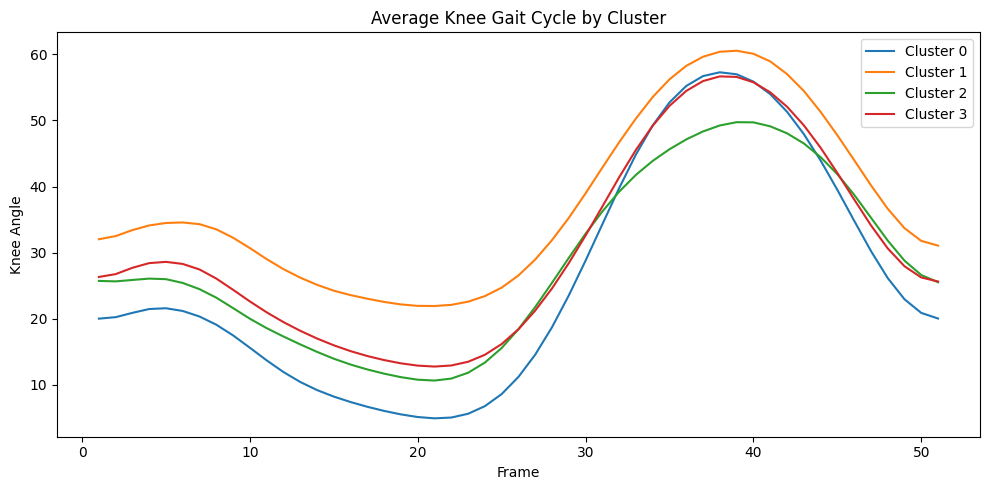

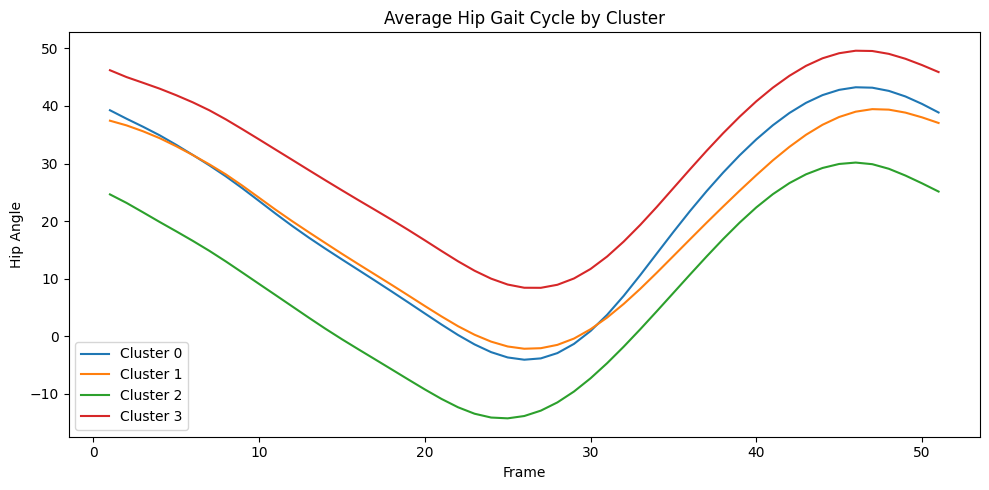

In [89]:
# Example usage:
analyze_gait_dataset(
    r"C:\Users\Admin\Desktop\CP\Data\processed\gait_data_processing\merged_df.csv",
    r"C:\Users\Admin\Desktop\CP\Outputs\results\datasetCPid"
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_25512\1501263844.py:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  train_df = train_df.interpolate(axis=0).fillna(method='bfill').fillna(method='ffill')
C:\Users\Admin\AppData\Local\Temp\ipykernel_25512\1501263844.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df = train_df.interpolate(axis=0).fillna(method='bfill').fillna(method='ffill')
C:\Users\Admin\AppData\Local\Temp\ipykernel_25512\1501263844.py:20: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  test_df = test_df.interpolate(axis=0).fillna(method='bfill').fillna(method='ffill')
C:\Users\Admin\AppData\Local\Temp\ipykernel_25512\15012638

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step


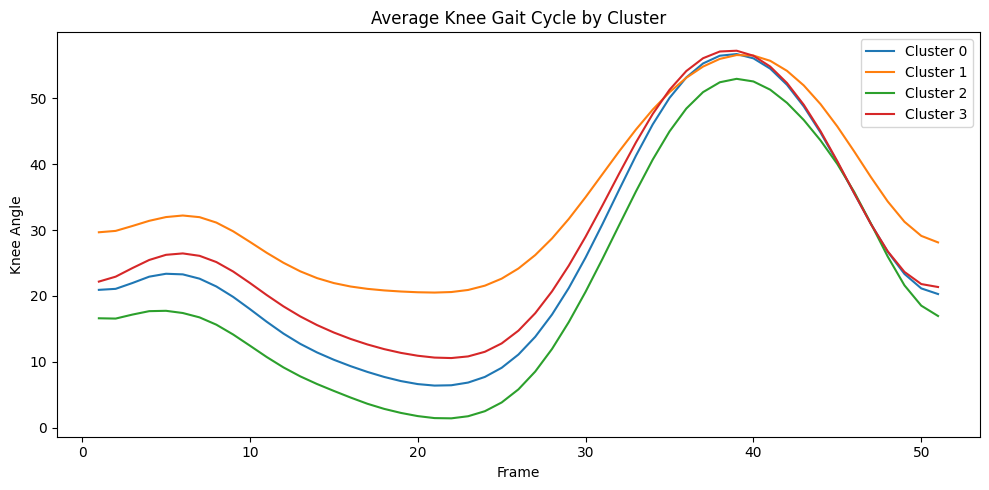

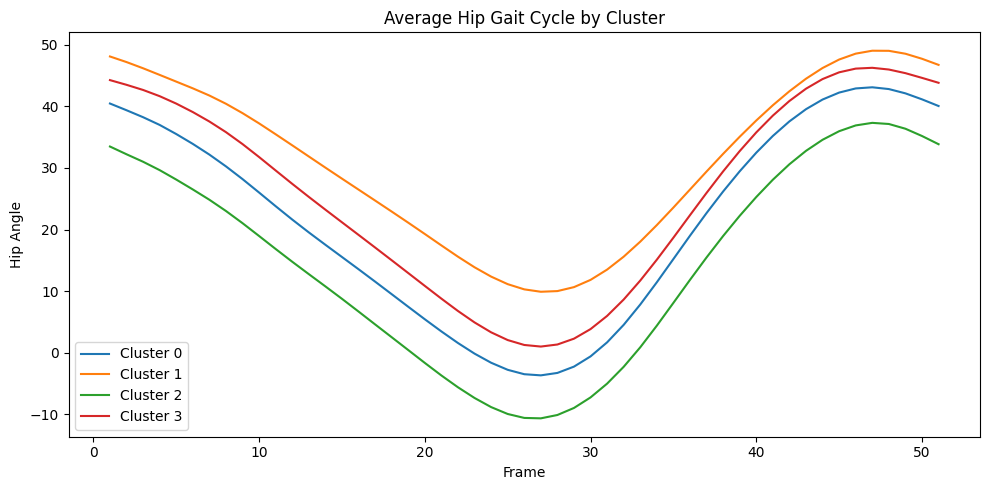

In [90]:
# Example usage:
analyze_gait_dataset(
    r"C:\Users\Admin\Desktop\CP\Data\processed\gait_data_processing\closest_side_to_reference.csv",
    r"C:\Users\Admin\Desktop\CP\Outputs\results\datasetCPid_number"
)

In [93]:
import pandas as pd

df_merged = pd.read_csv(r'C:\Users\Admin\Desktop\CP\Outputs\results\train_patient_clusters.csv')
df_original = pd.read_csv(r'C:\Users\Admin\Desktop\CP\Outputs\results\datasetCPid_number_clusters.csv')

# Convert both 'Patient ID' columns to string for safe merging
df_merged['Patient ID'] = df_merged['Patient ID'].astype(str)
df_original['Patient ID'] = df_original['Patient ID'].astype(str)

comparison = pd.merge(df_merged, df_original, on='Patient ID', suffixes=('_merged', '_original'))

diff = comparison[comparison['Cluster_merged'] != comparison['Cluster_original']]
print("Patients with different cluster assignments:")
print(diff)

diff.to_csv(r'C:\Users\Admin\Desktop\CP\Outputs\results\cluster_assignment_differences.csv', index=False)

Patients with different cluster assignments:
    Patient ID  Cluster_merged  Cluster_original
0            2               3                 0
1            5               1                 0
2            6               1                 0
3            7               3                 0
4            8               1                 0
..         ...             ...               ...
209        347               3                 0
210        348               3                 0
211        350               2                 3
212        351               0                 3
213        354               3                 2

[198 rows x 3 columns]


In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Admin\Desktop\CP\Outputs\results\train_patient_clusters.csv")

In [2]:
df

,Patient ID,Cluster
0,2,3
1,3,1
2,5,1
3,6,1
4,7,3
...,...,...
408,CP95,0
409,CP101,1
410,CP152,3
411,CP83,3


In [3]:
df['Cluster'].value_counts()

Cluster
3    132
1    104
0     90
2     87
Name: count, dtype: int64